# Exoplanet Transit
## A notebook-based first version built around real Kepler light curves

I want to start with one important clarification. This notebook is not a full exoplanet discovery pipeline that begins with arbitrary stars and ends with a discovery claim. That would be too broad for a first prototype and, more importantly, it would not match the exact type of archive objects I am using here. What I am building is a **transit candidate vetting prototype**.

That wording is not a downgrade. It is the more precise and more professional way to describe the work. I start from Kepler archive objects that are already considered transit-like enough to belong to the candidate-analysis workflow. I retrieve their light curves, search those light curves for the strongest repeated box-shaped dip, summarize the recovered signal using engineered features, and train a first classifier that tries to separate more planet-like cases from stronger non-planetary cases.

## Preface: the pipeline I am following and why I chose it

Before I write any code, I want to make the structure of the project explicit. I do not want the notebook to feel like a collection of disconnected cells. I want it to feel like a coherent pipeline where each stage has a purpose and prepares the next one.

This is the pipeline I am following in this prototype:

**Problem framing -> label design -> target selection -> light-curve retrieval -> cleaning and detrending -> transit search with BLS -> feature engineering -> classification -> evaluation -> error analysis -> next-step roadmap**

I chose this pipeline because it matches how the project should mature.

The first stage is **problem framing**. I define what I am trying to do and, just as importantly, what I am not claiming yet. This avoids building the wrong system for the wrong question.

The second stage is **label design**. A classifier is only as coherent as its labels. If the label meaning is vague, the model will also become vague. So before I train anything, I decide what the positive class means and what the negative class means.

The third stage is **target selection**. Once the labels are defined, I need a balanced and manageable set of examples. This is a six-day prototype, so I care more about a clean and explainable sample than about a huge one.

The fourth stage is **light-curve retrieval**. A row in an archive table is not yet the signal. I need the actual brightness measurements over time.

The fifth stage is **cleaning and detrending**. Raw light curves contain missing values, outliers, offsets, and long-timescale trends. A transit is a small, short-duration effect, so I want to suppress the slower background structure without damaging the shorter dips I care about.

The sixth stage is **transit search with BLS**. Box Least Squares is appropriate because a transit is closer to a repeating box-shaped dip than to a sinusoidal oscillation. I want the search method to match the physics of the event.

The seventh stage is **feature engineering**. The classifier will not look at the raw sequence directly in this first prototype. Instead, I will convert each recovered candidate into a numerical description of its period, depth, duration, significance, noise environment, and morphology.

The eighth stage is **classification**. Once the signal is represented as features, I can train a first model. I will begin with models that are fast, interpretable, and reasonable on small tabular datasets.

The ninth stage is **evaluation**. I do not want one flattering number. I want cross-validation for stability and a holdout set for unseen-case testing.

The tenth stage is **error analysis**. This is the part that separates a toy notebook from a serious one. I want to inspect what the model gets right, what it gets wrong, and why.

The final stage is the **next-step roadmap**. A prototype should not pretend to be final. It should make the next improvements obvious.

That is the structure I am going to follow all the way through the notebook.

## Project goal

My goal is to build a first machine-learning prototype that takes real Kepler transit-like candidates, extracts physically meaningful features from their light curves, and predicts whether their recovered signal behaves more like a confirmed planet case or more like a strong negative case.

## Environment note before I run anything

This notebook uses `lightkurve`, `astropy`, `scikit-learn`, and Jupyter widgets. In practice, the astronomy stack is usually smoother on Python 3.11, 3.12, or 3.13 than on Python 3.14.

In [1]:
# %pip install -q lightkurve pandas numpy matplotlib scikit-learn requests ipywidgets bokeh

In [2]:
from pathlib import Path
from io import StringIO
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import lightkurve as lk

from astropy.timeseries import BoxLeastSquares

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

C:\Users\eduar\Documents\exoplanet-transit-finder\.venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## Project settings

The sample size per class is deliberately modest. For a first prototype I care more about a smaller set of targets that I understand well than a larger set that I only process superficially. I also restrict the candidate period range. Long-period signals are harder to recover quickly because fewer transit events are observed in a finite time baseline. For a first version, it is more sensible to work in a period regime where repeated events are easier to recover and easier to explain.

I am also caching intermediate results. That does not make the notebook less scientific. It makes it demonstrable. The first run can do the heavier work, and later runs can reuse the cached data products and feature tables.

In [3]:
RANDOM_STATE = 42

N_CONFIRMED = 18
N_NEGATIVE = 18

MIN_PERIOD_DAYS = 0.75
MAX_PERIOD_DAYS = 20.0

PERIOD_GRID_SIZE = 2500
DURATION_GRID_HOURS = np.arange(1, 13, 1)
PHASE_BINS = 160

REBUILD_FEATURES = True

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
LIGHTKURVE_CACHE_DIR = DATA_DIR / "lightkurve_cache"

for folder in [DATA_DIR, RAW_DIR, PROCESSED_DIR, LIGHTKURVE_CACHE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TARGET_CACHE_PATH = PROCESSED_DIR / "selected_targets_v3.csv"
FEATURE_CACHE_PATH = PROCESSED_DIR / "transit_features_v3.csv"
FAILURE_CACHE_PATH = PROCESSED_DIR / "failed_targets_v3.csv"
CV_RESULTS_PATH = PROCESSED_DIR / "cross_validation_results_v3.csv"
FEATURE_IMPORTANCE_PATH = PROCESSED_DIR / "feature_importance_v3.csv"
PREDICTIONS_PATH = PROCESSED_DIR / "holdout_predictions_v3.csv"

# Problem framing

The first thing I want to defend is the task definition itself.

I am not starting from completely raw stars and asking whether a planet exists anywhere in the light curve. Instead, I am starting from Kepler archive objects that already belong to the transit-candidate world. That means this notebook is best described as a **candidate vetting** workflow.

Why does that matter? Because it changes how I think about the labels and the model. The model is not simply learning “dip versus no dip.” The negative cases can still contain repeated, convincing, transit-like behavior. That is exactly why this is a meaningful classification task. Some negative cases may be eclipsing binaries or other non-planetary configurations that still produce structured dimming events. So the model needs to learn the difference between “transit-like and more planet-like” versus “transit-like but less likely to be planetary.”

# Label design

This is one of the most important design choices in the notebook.

For the positive class, I use archive objects whose disposition is `CONFIRMED`.

For the negative class, I want something stronger than a random set of stars. The classifier should not learn the trivial difference between “interesting light curve” and “boring light curve.” It should learn a harder distinction. So the negative class comes from objects with archive disposition `FALSE POSITIVE`.

This is still a first prototype, so I am not pretending this is the perfect final benchmark design. But it is already much stronger than a naive “planet versus random star” setup because both classes come from the transit-candidate context.

The important thing is that the two classes live in the same general universe of archive objects, but they differ in how the archive ultimately interprets them.

## Accessing the archive

The NASA Exoplanet Archive exposes a TAP service. TAP stands for Table Access Protocol. I am using it because it lets me retrieve tables programmatically with SQL-like queries.

This matters because I want the notebook to be reproducible. I do not want to manually download one CSV today and then forget exactly how I got it tomorrow. By querying the archive directly from the notebook, I make the data access step part of the pipeline rather than something hidden outside it.

In [4]:
def run_tap_query(query: str, timeout: int = 180) -> pd.DataFrame:
    url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync"
    response = requests.get(url, params={"query": query, "format": "csv"}, timeout=timeout)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text))

In [5]:
def fetch_koi_table() -> pd.DataFrame:
    query = f"""
    select
        kepid,
        kepoi_name,
        koi_disposition,
        koi_period,
        koi_time0bk,
        koi_duration,
        koi_depth,
        koi_prad,
        koi_impact
    from cumulative
    where koi_disposition in ('CONFIRMED', 'FALSE POSITIVE')
      and koi_period between {MIN_PERIOD_DAYS} and {MAX_PERIOD_DAYS}
      and koi_duration is not null
      and koi_depth is not null
      and kepid is not null
    """
    df = run_tap_query(query)

    # One target star can have multiple KOIs.
    # For a clean first prototype I keep one row per star and prefer the deepest signal,
    # because the strongest transit-like event is usually the easiest one to recover
    # in a short notebook prototype.
    df = (
        df.sort_values(["kepid", "koi_depth"], ascending=[True, False])
          .drop_duplicates(subset=["kepid"], keep="first")
          .reset_index(drop=True)
    )
    return df

In [6]:
koi_df = fetch_koi_table()
koi_df.head()

,kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad,koi_impact
0,757450,K00889.01,CONFIRMED,8.884923,169.991686,2.07004,16053.4,10.51,0.069
1,892772,K01009.01,FALSE POSITIVE,5.092465,357.535940,3.65900,254.0,1.17,0.161
2,1026032,K06252.01,FALSE POSITIVE,8.460439,133.774490,4.73492,76412.9,36.62,1.061
3,1161345,K00984.01,CONFIRMED,4.287467,262.062450,1.56930,790.1,2.29,0.374
4,1432789,K00992.01,CONFIRMED,9.931463,136.491280,5.67800,398.6,2.41,0.037


## Reading the archive table carefully

Each row in the table above identifies one Kepler target and one archive-side interpretation of its transit-like behavior.

The `kepid` is the Kepler target identifier. The `kepoi_name` is the specific Kepler Object of Interest name. The columns `koi_period`, `koi_duration`, and `koi_depth` are archive-side transit parameters associated with that KOI.

I am not going to use those archive solution parameters as direct training features. I keep them mainly for quality control. They help me check whether my own signal recovery from the light curve is behaving sensibly. If my recovered period is usually close to the archive period, that is a reassuring sign. If it is often far away, something in my search configuration or preprocessing probably needs attention.

# Target selection

The next step is to turn the larger archive pool into a balanced prototype sample.

I do this for two reasons. First, a balanced sample makes the classification stage easier to interpret in a first prototype. Second, a smaller curated subset keeps the notebook runnable and explainable.

The goal here is not to maximize sample size at all costs. The goal is to get a clean first end-to-end run that already proves the project is alive.

In [7]:
def build_balanced_target_set(koi_df: pd.DataFrame) -> pd.DataFrame:
    confirmed = (
        koi_df[koi_df["koi_disposition"] == "CONFIRMED"]
        .sample(n=min(N_CONFIRMED, (koi_df["koi_disposition"] == "CONFIRMED").sum()), random_state=RANDOM_STATE)
        .copy()
    )
    negative = (
        koi_df[koi_df["koi_disposition"] == "FALSE POSITIVE"]
        .sample(n=min(N_NEGATIVE, (koi_df["koi_disposition"] == "FALSE POSITIVE").sum()), random_state=RANDOM_STATE)
        .copy()
    )

    confirmed["label"] = 1
    negative["label"] = 0

    targets = (
        pd.concat([confirmed, negative], ignore_index=True)
          .sample(frac=1.0, random_state=RANDOM_STATE)
          .reset_index(drop=True)
    )
    return targets

targets_df = build_balanced_target_set(koi_df)
targets_df.to_csv(TARGET_CACHE_PATH, index=False)

print(f"Prototype target count: {len(targets_df)}")
targets_df.head(10)

Prototype target count: 36


,kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad,koi_impact,label
0,9593773,K04240.01,FALSE POSITIVE,3.133936,133.545800,4.4770,203.7,1.58,0.768,0
1,10166274,K01078.02,CONFIRMED,6.877446,132.084260,1.3692,1632.3,2.05,0.790,1
2,12935144,K02847.01,FALSE POSITIVE,1.099291,131.502420,1.7650,282.6,1.37,0.077,0
3,8262210,K01073.01,FALSE POSITIVE,1.613001,178.528460,2.3940,104.1,1.25,0.448,0
4,5080636,K01843.01,CONFIRMED,4.194497,134.135110,1.7807,660.7,1.57,0.863,1
5,4678919,K04219.01,FALSE POSITIVE,1.878853,133.088610,3.3020,120.9,0.97,0.513,0
6,11463211,K00770.01,FALSE POSITIVE,1.506354,170.998064,1.5155,2211.7,4.53,0.860,0
7,10925104,K00156.03,CONFIRMED,11.776132,142.705753,2.8971,1430.8,2.08,0.540,1
8,3346154,K02723.01,CONFIRMED,1.952711,133.160986,0.8720,403.0,2.58,0.962,1
9,3444588,K01202.01,CONFIRMED,0.928310,133.803580,1.1899,376.2,1.16,0.181,1


In [8]:
targets_df["label"].map({1: "Confirmed", 0: "Negative"}).value_counts()

label
Negative     18
Confirmed    18
Name: count, dtype: int64

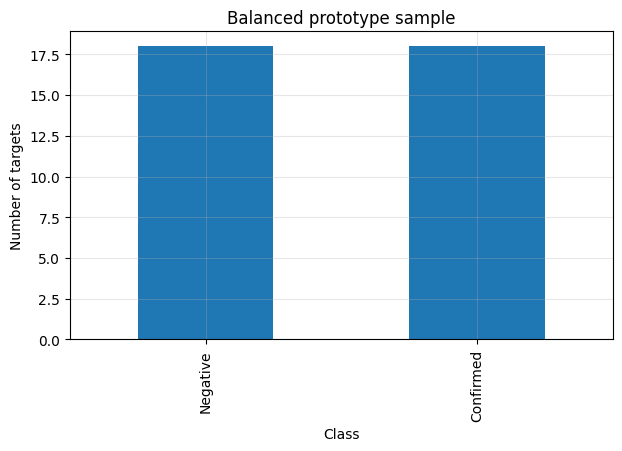

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
targets_df["label"].map({1: "Confirmed", 0: "Negative"}).value_counts().plot(kind="bar", ax=ax)
ax.set_title("Balanced prototype sample")
ax.set_xlabel("Class")
ax.set_ylabel("Number of targets")
plt.show()

# Light-curve retrieval

A table row is not yet the scientific signal. To reach the signal, I need the brightness measurements of the star across time.

This is where Lightkurve is useful. It already knows how to search mission archives for Kepler data, download available light-curve products, and represent them in a form that can be stitched, cleaned, flattened, and inspected.

I am using long-cadence Kepler products for this first prototype because they are enough to demonstrate the workflow without making the notebook unnecessarily heavy.

# Cleaning and detrending

This stage matters a lot because a transit is small. 

If I leave NaNs in the data, the signal-search stage cannot use those points correctly. If I leave strong outliers, they can distort the periodogram. If I keep large long-term trends, those trends can compete with the short-duration transit-like dips I actually care about.

So the preparation sequence is deliberate. I normalize individual segments, stitch them together, remove NaNs, remove large outliers, and then flatten the light curve to suppress the slower baseline structure while preserving the shorter dips.

In [10]:
def choose_window_length(n_points: int) -> int:
    candidate = max(101, min(901, n_points // 20))
    if candidate % 2 == 0:
        candidate += 1
    return candidate


def download_and_prepare_lightcurve(kepid: int):
    search = lk.search_lightcurve(
        f"KIC {int(kepid)}",
        mission="Kepler",
        author="Kepler",
        cadence="long",
    )

    if len(search) == 0:
        raise ValueError("No Kepler light-curve products were found for this target.")

    collection = search.download_all(download_dir=str(LIGHTKURVE_CACHE_DIR))
    if collection is None or len(collection) == 0:
        raise ValueError("Archive search succeeded, but no downloadable light curves were returned.")

    stitched = collection.stitch(corrector_func=lambda lc: lc.remove_nans().normalize())
    stitched = stitched.remove_nans().remove_outliers(sigma=5)

    window_length = choose_window_length(len(stitched.time))
    flattened = stitched.flatten(window_length=window_length, polyorder=2, break_tolerance=5)
    flattened = flattened.remove_nans()

    if len(flattened.time) < 500:
        raise ValueError("Too few cadences remain after cleaning and flattening.")

    return stitched, flattened

# Transit search with Box Least Squares

This is the heart of the signal-search stage.

A planetary transit does not look like a smooth sine wave. Most of the time the flux stays near baseline, then it drops for a relatively short interval, then it returns. That means I need a search method designed for repeating box-shaped dimming events, not for smooth oscillations.

That is why I use **Box Least Squares**, usually shortened to **BLS**. BLS scans many trial periods and durations and asks which repeating box-shaped event best matches the observed data. In other words, it searches for the best candidate transit-like pattern in the light curve.

I also like BLS for a first prototype because its outputs are easy to interpret. The best period, best duration, best depth, and best power describe the strongest recovered event in a way that I can later inspect and explain.

In [11]:
def robust_flux_arrays(lightcurve):
    time = np.asarray(lightcurve.time.value, dtype=float)
    flux = np.asarray(getattr(lightcurve.flux, "value", lightcurve.flux), dtype=float)

    if getattr(lightcurve, "flux_err", None) is not None:
        flux_err = np.asarray(getattr(lightcurve.flux_err, "value", lightcurve.flux_err), dtype=float)
        if not np.isfinite(flux_err).all() or np.nanmedian(flux_err) <= 0:
            flux_err = np.full_like(flux, np.nanstd(flux))
    else:
        flux_err = np.full_like(flux, np.nanstd(flux))

    mask = np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err)
    time = time[mask]
    flux = flux[mask]
    flux_err = flux_err[mask]

    if len(time) < 500:
        raise ValueError("Too few usable observations remain after filtering.")

    return time, flux, flux_err


def mad_normal(x):
    median = np.nanmedian(x)
    return 1.4826 * np.nanmedian(np.abs(x - median))


def build_period_duration_grids():
    periods = np.linspace(MIN_PERIOD_DAYS, MAX_PERIOD_DAYS, PERIOD_GRID_SIZE)
    durations = DURATION_GRID_HOURS / 24.0
    return periods, durations


def fold_arrays(time, flux, period, t0):
    phase = ((time - t0 + 0.5 * period) % period) / period - 0.5
    order = np.argsort(phase)
    return phase[order], flux[order]


def phase01_arrays(time, flux, period, t0):
    phase01 = ((time - t0) % period) / period
    order = np.argsort(phase01)
    return phase01[order], flux[order]

# Feature engineering

This is the bridge between the astrophysical signal and the machine-learning model.

I am not feeding the raw flux sequence directly into the classifier in this first version. Instead, I turn each target into a compact numerical description of the strongest transit-like event recovered by BLS.

I want different kinds of features.

Some features describe the candidate event itself, such as the recovered period, duration, depth, and signal strength.

Some features describe the noise environment, because a transit depth only means something in relation to the variability and scatter around it.

Some features describe morphology. These are especially useful because false positives are often not random noise. They can look structured. So I want features that capture odd-even depth differences, possible secondary events, phase-folded shape quality, and how sharp or symmetric the recovered event looks.

I like this approach because every feature has a reason to exist. I can explain why it is in the model.

In [12]:
def binned_phase_curve(phase, flux, n_bins=PHASE_BINS, low=-0.5, high=0.5):
    bins = np.linspace(low, high, n_bins + 1)
    idx = np.digitize(phase, bins) - 1
    binned = np.array([
        np.nanmedian(flux[idx == i]) if np.any(idx == i) else np.nan
        for i in range(n_bins)
    ])
    return binned


def circular_distance(phase01, center):
    d = np.abs(phase01 - center)
    return np.minimum(d, 1 - d)


def event_depth_from_phase01(phase01, flux, center=0.0, half_width=0.03, exclusion_width=0.08):
    target_mask = circular_distance(phase01, center) <= half_width
    baseline_mask = (
        (circular_distance(phase01, center) > exclusion_width) &
        (circular_distance(phase01, 0.5) > exclusion_width)
    )

    if target_mask.sum() < 3 or baseline_mask.sum() < 10:
        return np.nan

    baseline = np.nanmedian(flux[baseline_mask])
    event_flux = np.nanmedian(flux[target_mask])
    return baseline - event_flux


def compute_odd_even_depth_difference(time, flux, period, duration, t0):
    centers = []
    k_min = int(np.floor((time.min() - t0) / period)) - 1
    k_max = int(np.ceil((time.max() - t0) / period)) + 1

    for k in range(k_min, k_max + 1):
        centers.append(t0 + k * period)

    depths = []
    for center in centers:
        in_mask = np.abs(time - center) <= (duration / 2)
        local_mask = np.abs(time - center) <= (2 * duration)
        oot_mask = local_mask & (~in_mask)

        if in_mask.sum() >= 3 and oot_mask.sum() >= 5:
            baseline = np.nanmedian(flux[oot_mask])
            event = np.nanmedian(flux[in_mask])
            depths.append(baseline - event)

    if len(depths) < 4:
        return np.nan, len(depths)

    odd_depth = np.nanmedian(depths[::2])
    even_depth = np.nanmedian(depths[1::2])
    return np.abs(odd_depth - even_depth), len(depths)


def compute_phase_symmetry_metric(phase, flux, window=0.08, n_bins=40):
    mask = np.abs(phase) <= window
    if mask.sum() < 20:
        return np.nan

    bins = np.linspace(-window, window, n_bins + 1)
    idx = np.digitize(phase[mask], bins) - 1
    binned = np.array([
        np.nanmedian(flux[mask][idx == i]) if np.any(idx == i) else np.nan
        for i in range(n_bins)
    ])

    half = n_bins // 2
    left = binned[:half]
    right = binned[half:][::-1]
    valid = np.isfinite(left) & np.isfinite(right)

    if valid.sum() < 5:
        return np.nan

    return np.nanmean(np.abs(left[valid] - right[valid]))


def compute_transit_sharpness(phase, flux, inner=0.01, shoulder_low=0.02, shoulder_high=0.05):
    inner_mask = np.abs(phase) <= inner
    shoulder_mask = (np.abs(phase) >= shoulder_low) & (np.abs(phase) <= shoulder_high)

    if inner_mask.sum() < 3 or shoulder_mask.sum() < 3:
        return np.nan

    center_flux = np.nanmedian(flux[inner_mask])
    shoulder_flux = np.nanmedian(flux[shoulder_mask])
    return shoulder_flux - center_flux

In [13]:
def extract_transit_features(flattened_lc, catalog_period=None):
    time, flux, flux_err = robust_flux_arrays(flattened_lc)
    periods, durations = build_period_duration_grids()

    bls = BoxLeastSquares(time, flux, dy=flux_err)
    results = bls.power(periods, durations, objective="snr")

    powers = np.asarray(results.power, dtype=float)
    best_idx = int(np.nanargmax(powers))

    best_period = float(np.asarray(results.period)[best_idx])
    best_duration = float(np.asarray(results.duration)[best_idx])
    best_t0 = float(np.asarray(results.transit_time)[best_idx])
    best_depth = float(np.asarray(results.depth)[best_idx])
    best_power = float(np.asarray(results.power)[best_idx])
    best_depth_snr = float(np.asarray(results.depth_snr)[best_idx])

    transit_mask = bls.transit_mask(time, best_period, best_duration, best_t0)
    if transit_mask.sum() == 0 or (~transit_mask).sum() == 0:
        raise ValueError("BLS transit mask is empty or degenerate.")

    phase, folded_flux = fold_arrays(time, flux, best_period, best_t0)
    phase01, folded_flux01 = phase01_arrays(time, flux, best_period, best_t0)

    binned = binned_phase_curve(phase, folded_flux)
    baseline = np.nanmedian(binned)
    minimum = np.nanmin(binned)
    phase_curve_depth = baseline - minimum
    phase_curve_scatter = np.nanstd(binned)

    primary_depth = event_depth_from_phase01(phase01, folded_flux01, center=0.0, half_width=0.03)
    secondary_depth = event_depth_from_phase01(phase01, folded_flux01, center=0.5, half_width=0.03)
    odd_even_diff, n_measured_transits = compute_odd_even_depth_difference(
        time, flux, best_period, best_duration, best_t0
    )
    symmetry_metric = compute_phase_symmetry_metric(phase, folded_flux)
    transit_sharpness = compute_transit_sharpness(phase, folded_flux)

    in_flux = flux[transit_mask]
    out_flux = flux[~transit_mask]

    cdpp_3h_ppm = float(flattened_lc.estimate_cdpp(transit_duration=6))
    cdpp_6p5h_ppm = float(flattened_lc.estimate_cdpp(transit_duration=13))
    cdpp_12h_ppm = float(flattened_lc.estimate_cdpp(transit_duration=24))

    power_median = float(np.nanmedian(powers))
    power_std = float(np.nanstd(powers))
    power_zscore = np.nan if power_std == 0 else (best_power - power_median) / power_std

    best_depth_ppm = best_depth * 1e6
    primary_depth_ppm = np.nan if not np.isfinite(primary_depth) else primary_depth * 1e6
    secondary_depth_ppm = np.nan if not np.isfinite(secondary_depth) else secondary_depth * 1e6

    feature_row = {
        "n_points": len(time),
        "time_baseline_days": float(time.max() - time.min()),
        "flux_std": float(np.nanstd(flux)),
        "flux_mad": float(mad_normal(flux)),
        "cdpp_3h_ppm": cdpp_3h_ppm,
        "cdpp_6p5h_ppm": cdpp_6p5h_ppm,
        "cdpp_12h_ppm": cdpp_12h_ppm,
        "bls_best_period": best_period,
        "bls_best_duration_hours": best_duration * 24.0,
        "bls_best_depth_ppm": best_depth_ppm,
        "bls_best_power": best_power,
        "bls_best_depth_snr": best_depth_snr,
        "bls_power_zscore": power_zscore,
        "duty_cycle": best_duration / best_period,
        "estimated_transit_count": (time.max() - time.min()) / best_period,
        "in_transit_fraction": float(transit_mask.mean()),
        "transit_contrast": float(np.nanmedian(out_flux) - np.nanmedian(in_flux)),
        "phase_curve_depth": float(phase_curve_depth),
        "phase_curve_scatter": float(phase_curve_scatter),
        "primary_depth_ppm": primary_depth_ppm,
        "secondary_depth_ppm": secondary_depth_ppm,
        "secondary_to_primary_ratio": np.nan if not np.isfinite(primary_depth_ppm) or primary_depth_ppm == 0 else secondary_depth_ppm / primary_depth_ppm,
        "odd_even_depth_difference": float(odd_even_diff) if np.isfinite(odd_even_diff) else np.nan,
        "n_measured_transits": int(n_measured_transits),
        "phase_symmetry_metric": float(symmetry_metric) if np.isfinite(symmetry_metric) else np.nan,
        "transit_sharpness": float(transit_sharpness) if np.isfinite(transit_sharpness) else np.nan,
        "depth_over_cdpp_6p5h": np.nan if cdpp_6p5h_ppm == 0 else best_depth_ppm / cdpp_6p5h_ppm,
        "depth_over_flux_mad": np.nan if mad_normal(flux) == 0 else best_depth / mad_normal(flux),
    }

    if catalog_period is not None and np.isfinite(catalog_period):
        feature_row["catalog_period_days"] = float(catalog_period)
        feature_row["period_recovery_abs_error_days"] = abs(best_period - float(catalog_period))
        feature_row["period_recovery_relative_error"] = abs(best_period - float(catalog_period)) / float(catalog_period)

    return feature_row, results

## Building the feature table

This is where the notebook stops being only an astronomy workflow and becomes a machine-learning dataset.

For each target, I download and prepare the light curve, run the BLS search, extract the features, and log any failures. I do not hide failures because failures are part of the real behavior of a pipeline. If a target cannot be downloaded cleanly or becomes too short after cleaning, that is worth recording.

A professional notebook does not quietly discard problems and then behave as if the workflow was perfectly smooth.

In [14]:
def build_feature_table(targets: pd.DataFrame):
    records = []
    failures = []

    for row in targets.itertuples(index=False):
        try:
            _, flattened = download_and_prepare_lightcurve(row.kepid)
            features, _ = extract_transit_features(flattened, catalog_period=row.koi_period)

            record = {
                "kepid": int(row.kepid),
                "kepoi_name": row.kepoi_name,
                "koi_disposition": row.koi_disposition,
                "label": int(row.label),
                "catalog_depth_ppm": row.koi_depth,
                "catalog_duration_hours": row.koi_duration,
                "catalog_period_days": row.koi_period,
            }
            record.update(features)
            records.append(record)
        except Exception as exc:
            failures.append({
                "kepid": int(row.kepid),
                "kepoi_name": row.kepoi_name,
                "koi_disposition": row.koi_disposition,
                "label": int(row.label),
                "error": str(exc),
            })

    return pd.DataFrame(records), pd.DataFrame(failures)

In [15]:
if REBUILD_FEATURES or not FEATURE_CACHE_PATH.exists():
    features_df, failures_df = build_feature_table(targets_df)
    features_df.to_csv(FEATURE_CACHE_PATH, index=False)
    failures_df.to_csv(FAILURE_CACHE_PATH, index=False)
else:
    features_df = pd.read_csv(FEATURE_CACHE_PATH)
    failures_df = pd.read_csv(FAILURE_CACHE_PATH) if FAILURE_CACHE_PATH.exists() else pd.DataFrame()

print("Successful targets:", len(features_df))
print("Failed targets:", len(failures_df))
features_df.head()

Successful targets: 36
Failed targets: 0


,kepid,kepoi_name,koi_disposition,label,catalog_depth_ppm,catalog_duration_hours,catalog_period_days,n_points,time_baseline_days,flux_std,flux_mad,cdpp_3h_ppm,cdpp_6p5h_ppm,cdpp_12h_ppm,bls_best_period,bls_best_duration_hours,bls_best_depth_ppm,bls_best_power,bls_best_depth_snr,bls_power_zscore,duty_cycle,estimated_transit_count,in_transit_fraction,transit_contrast,phase_curve_depth,phase_curve_scatter,primary_depth_ppm,secondary_depth_ppm,secondary_to_primary_ratio,odd_even_depth_difference,n_measured_transits,phase_symmetry_metric,transit_sharpness,depth_over_cdpp_6p5h,depth_over_flux_mad,period_recovery_abs_error_days,period_recovery_relative_error
0,9593773,K04240.01,FALSE POSITIVE,0,203.7,4.4770,3.133936,63111,1421.236090,0.000512,0.000493,0.000198,0.000125,0.000078,12.535714,3.0,241.102333,12.857279,12.857279,12.101512,0.009972,113.374959,0.009982,0.000239,0.000220,0.000053,38.032643,45.894255,1.206707,0.000084,103,0.000042,0.000173,1.926748e+06,0.489294,9.401779,2.999991
1,10166274,K01078.02,CONFIRMED,1,1632.3,1.3692,6.877446,51717,1459.489129,0.000995,0.000960,0.000313,0.000201,0.000129,3.353641,1.0,1045.567295,44.411858,44.411858,8.595569,0.012424,435.195338,0.012452,0.001029,0.001054,0.000137,272.562922,-21.573504,-0.079151,0.000089,12,0.000085,0.000960,5.195044e+06,1.088794,3.523805,0.512371
2,12935144,K02847.01,FALSE POSITIVE,0,282.6,1.7650,1.099291,64735,1459.489403,0.000824,0.000784,0.000308,0.000192,0.000121,14.869748,11.0,153.731028,9.904530,9.904530,5.159251,0.030823,98.151590,0.031019,0.000141,0.000178,0.000073,95.922262,-69.248476,-0.721923,0.000073,93,0.000072,0.000063,7.998061e+05,0.196068,13.770457,12.526669
3,8262210,K01073.01,FALSE POSITIVE,0,104.1,2.3940,1.613001,63100,1421.235719,0.000296,0.000288,0.000121,0.000078,0.000048,1.612745,7.0,40.706343,15.150245,15.150245,14.075486,0.180851,881.252543,0.180571,0.000037,0.000073,0.000026,60.621269,26.136390,0.431142,0.000011,819,0.000017,0.000023,5.214297e+05,0.141514,0.000256,0.000159
4,5080636,K01843.01,CONFIRMED,1,660.7,1.7807,4.194497,50173,1426.446467,0.001581,0.000841,0.000187,0.000136,0.000096,17.157563,12.0,802.943414,116.927792,116.927792,5.705798,0.029142,83.138058,0.028462,0.000487,0.000553,0.000277,484.859519,-455.392333,-0.939225,0.000006,60,0.000049,0.000013,5.899095e+06,0.954471,12.963066,3.090494


# Pre-model sanity checks

Before I fit anything, I want to look at what feature extraction actually produced.

I want to know whether the class balance survived this stage, because if one class fails much more than the other, that can bias the prototype.

I want to know where missing values appear, because some features require enough phase coverage or enough recovered events and may legitimately be missing in a few cases.

I also want to inspect the numerical ranges, because if the recovered signal summaries look completely unreasonable, the model will not rescue the situation.

In [16]:
features_df.groupby(["label", "koi_disposition"]).size()

label  koi_disposition
0      FALSE POSITIVE     18
1      CONFIRMED          18
dtype: int64

In [17]:
features_df.isna().mean().sort_values(ascending=False).head(20)

transit_sharpness          0.027778
kepoi_name                 0.000000
koi_disposition            0.000000
label                      0.000000
kepid                      0.000000
catalog_depth_ppm          0.000000
catalog_duration_hours     0.000000
n_points                   0.000000
catalog_period_days        0.000000
flux_std                   0.000000
flux_mad                   0.000000
cdpp_3h_ppm                0.000000
time_baseline_days         0.000000
cdpp_12h_ppm               0.000000
bls_best_period            0.000000
bls_best_duration_hours    0.000000
bls_best_depth_ppm         0.000000
bls_best_power             0.000000
bls_best_depth_snr         0.000000
bls_power_zscore           0.000000
dtype: float64

In [18]:
preview_cols = [
    "bls_best_period", "bls_best_duration_hours", "bls_best_depth_ppm",
    "bls_best_depth_snr", "cdpp_6p5h_ppm", "depth_over_cdpp_6p5h",
    "secondary_depth_ppm", "odd_even_depth_difference", "period_recovery_relative_error"
]
features_df[preview_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
bls_best_period,36.0,9.945125e+00,4.612978e+00,1.612745,5.997724e+00,1.049440e+01,1.281880e+01,1.874440e+01
bls_best_duration_hours,36.0,7.083333e+00,4.364631e+00,1.000000,3.000000e+00,6.500000e+00,1.200000e+01,1.200000e+01
bls_best_depth_ppm,36.0,1.594561e+03,3.550340e+03,40.706343,1.518078e+02,2.984275e+02,1.053255e+03,1.717944e+04
bls_best_depth_snr,36.0,3.273830e+02,8.154885e+02,8.878332,1.825595e+01,3.976558e+01,1.362262e+02,3.309344e+03
cdpp_6p5h_ppm,36.0,3.085609e-04,6.398341e-04,0.000027,7.659991e-05,9.750709e-05,1.944734e-04,3.277814e-03
depth_over_cdpp_6p5h,36.0,5.432790e+06,9.850166e+06,521429.656553,1.920185e+06,2.639536e+06,5.262920e+06,5.739354e+07
secondary_depth_ppm,36.0,-1.334890e+02,1.757895e+03,-6333.746644,-5.544649e+01,-4.664477e+00,2.622525e+01,5.138186e+03
odd_even_depth_difference,36.0,1.397597e-04,2.967714e-04,0.000002,1.035320e-05,3.710184e-05,1.091362e-04,1.442246e-03
period_recovery_relative_error,36.0,3.679346e+00,4.025389e+00,0.000003,5.234083e-01,1.924084e+00,5.241647e+00,1.299983e+01


In [19]:
if len(failures_df) > 0:
    failures_df.head(10)
else:
    print("No failures were logged in this run.")

No failures were logged in this run.


## Early visual inspection

I do not want the first time I look at separation to be after the model already produced a metric. I prefer to inspect a few feature distributions directly.

If the feature engineering is doing useful work, I should expect at least some structure in quantities like recovered signal-to-noise, depth relative to CDPP, odd-even difference, and secondary-event behavior. I am not expecting perfect separation. I am only looking for enough structure to justify the modeling stage.

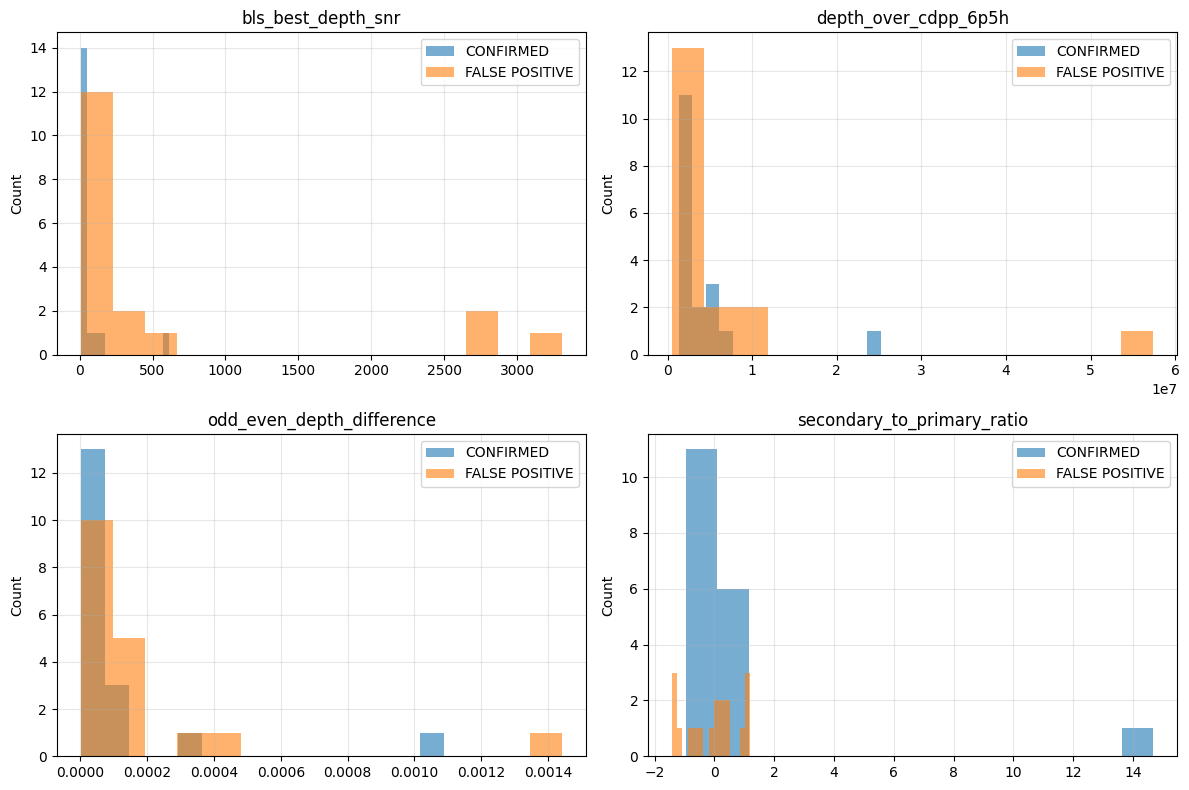

In [20]:
plot_features = [
    "bls_best_depth_snr",
    "depth_over_cdpp_6p5h",
    "odd_even_depth_difference",
    "secondary_to_primary_ratio",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.ravel(), plot_features):
    for disposition, group in features_df.groupby("koi_disposition"):
        series = group[feature].replace([np.inf, -np.inf], np.nan).dropna()
        if len(series) > 0:
            ax.hist(series, bins=15, alpha=0.6, label=disposition)
    ax.set_title(feature)
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# Looking at actual targets

For that reason I inspect real targets visually. For each example I show the stitched light curve, the BLS periodogram, and the phase-folded event around the recovered transit. This keeps the machine-learning stage tied to the original astrophysical signal.

In [21]:
def plot_target_diagnostics(kepid: int, title_prefix: str = ""):
    stitched, flattened = download_and_prepare_lightcurve(kepid)
    features, bls_results = extract_transit_features(flattened)

    time_raw = stitched.time.value
    flux_raw = np.asarray(getattr(stitched.flux, "value", stitched.flux), dtype=float)

    time = flattened.time.value
    flux = np.asarray(getattr(flattened.flux, "value", flattened.flux), dtype=float)

    periods = np.asarray(bls_results.period, dtype=float)
    powers = np.asarray(bls_results.power, dtype=float)
    best_idx = int(np.argmax(powers))

    best_period = float(np.asarray(bls_results.period)[best_idx])
    best_t0 = float(np.asarray(bls_results.transit_time)[best_idx])

    phase, folded_flux = fold_arrays(time, flux, best_period, best_t0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].plot(time_raw, flux_raw, ".", ms=1, alpha=0.6)
    axes[0].set_title(f"{title_prefix}Stitched light curve")
    axes[0].set_xlabel("Time [BKJD]")
    axes[0].set_ylabel("Normalized flux")

    axes[1].plot(periods, powers, lw=1.5)
    axes[1].axvline(best_period, linestyle="--")
    axes[1].set_title("BLS periodogram")
    axes[1].set_xlabel("Period [days]")
    axes[1].set_ylabel("BLS power")

    axes[2].plot(phase, folded_flux, ".", ms=2, alpha=0.45)
    axes[2].set_xlim(-0.12, 0.12)
    axes[2].set_title("Phase-folded signal near primary event")
    axes[2].set_xlabel("Orbital phase")
    axes[2].set_ylabel("Flattened flux")

    plt.tight_layout()
    plt.show()

    return features

In [22]:
example_confirmed = int(features_df.loc[features_df["label"] == 1, "kepid"].iloc[0])
example_negative = int(features_df.loc[features_df["label"] == 0, "kepid"].iloc[0])

print("Example confirmed KIC:", example_confirmed)
print("Example negative KIC:", example_negative)

Example confirmed KIC: 10166274
Example negative KIC: 9593773


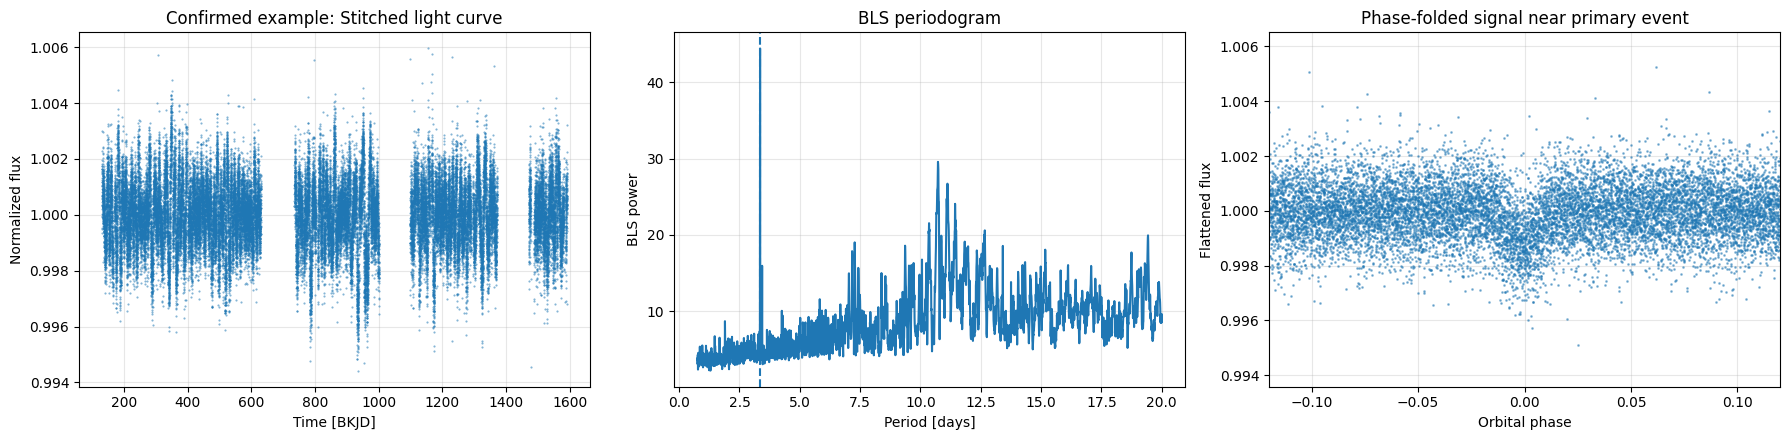

{'n_points': 51717,
 'time_baseline_days': 1459.4891285179692,
 'flux_std': 0.0009952772528597001,
 'flux_mad': 0.0009602981203594905,
 'cdpp_3h_ppm': 0.0003126372727265321,
 'cdpp_6p5h_ppm': 0.000201262445304238,
 'cdpp_12h_ppm': 0.00012875177825552388,
 'bls_best_period': 3.353641456582633,
 'bls_best_duration_hours': 1.0,
 'bls_best_depth_ppm': 1045.5672951996412,
 'bls_best_power': 44.41185788139805,
 'bls_best_depth_snr': 44.41185788139805,
 'bls_power_zscore': 8.59556886899804,
 'duty_cycle': 0.012424305700563791,
 'estimated_transit_count': np.float64(435.19533838456044),
 'in_transit_fraction': 0.012452385095809888,
 'transit_contrast': 0.001028584268393029,
 'phase_curve_depth': 0.0010540559219986978,
 'phase_curve_scatter': 0.00013705437705311484,
 'primary_depth_ppm': np.float64(272.56292235722236),
 'secondary_depth_ppm': np.float64(-21.573504056071613),
 'secondary_to_primary_ratio': np.float64(-0.07915054575103678),
 'odd_even_depth_difference': 8.883887379385058e-05,
 'n

In [23]:
confirmed_example_features = plot_target_diagnostics(example_confirmed, title_prefix="Confirmed example: ")
confirmed_example_features

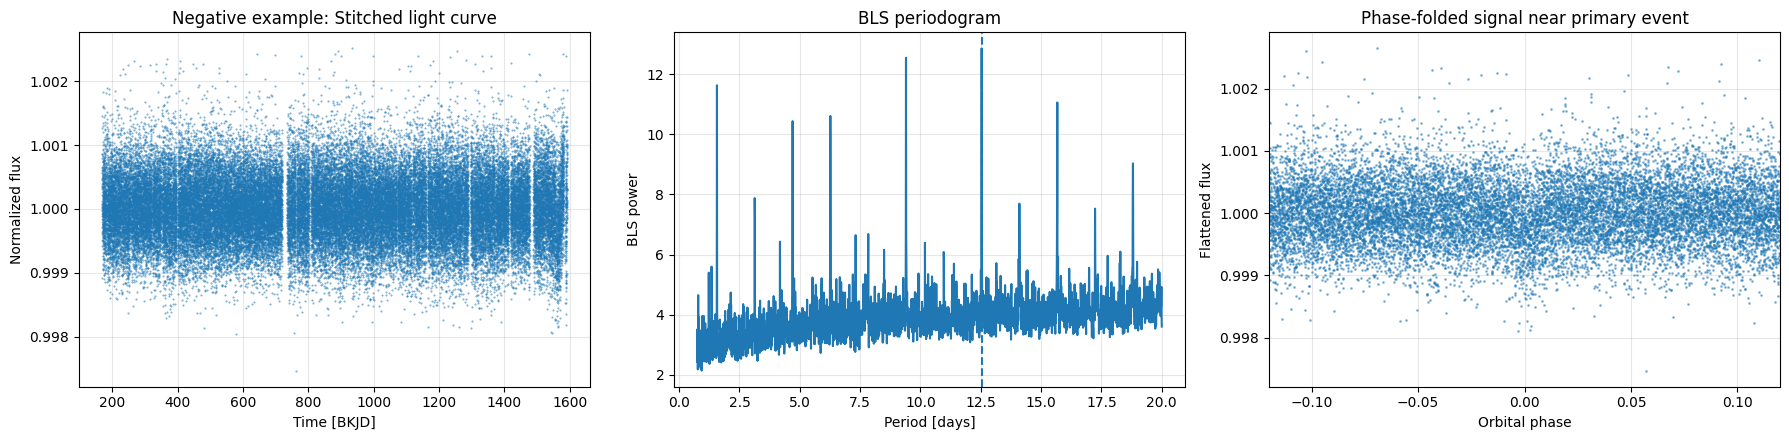

{'n_points': 63111,
 'time_baseline_days': 1421.2360904312445,
 'flux_std': 0.0005117563005479622,
 'flux_mad': 0.0004927552941665772,
 'cdpp_3h_ppm': 0.00019795594871290867,
 'cdpp_6p5h_ppm': 0.00012513434896476352,
 'cdpp_12h_ppm': 7.770282323007838e-05,
 'bls_best_period': 12.535714285714286,
 'bls_best_duration_hours': 3.0,
 'bls_best_depth_ppm': 241.10233342276948,
 'bls_best_power': 12.857279060137875,
 'bls_best_depth_snr': 12.857279060137875,
 'bls_power_zscore': 12.101512224359587,
 'duty_cycle': 0.009971509971509971,
 'estimated_transit_count': np.float64(113.37495878084002),
 'in_transit_fraction': 0.009982411940866093,
 'transit_contrast': 0.0002391335392639693,
 'phase_curve_depth': 0.00021978541185763145,
 'phase_curve_scatter': 5.349626297168348e-05,
 'primary_depth_ppm': np.float64(38.032642933338856),
 'secondary_depth_ppm': np.float64(45.89425545509229),
 'secondary_to_primary_ratio': np.float64(1.2067069736787097),
 'odd_even_depth_difference': 8.383930556271624e-05,

In [24]:
negative_example_features = plot_target_diagnostics(example_negative, title_prefix="Negative example: ")
negative_example_features

# Classification

For a first prototype, I do not need a giant model. I need models that are fast, understandable, and appropriate for small tabular data.

I start with two choices.

The first is logistic regression. I like it because it is a disciplined baseline. If logistic regression already performs above chance, that tells me the feature engineering itself contains useful structure.

The second is a random forest. I add it because the relationship between transit features is not necessarily linear. A random forest can capture non-linear splits and feature interactions without turning the notebook into a black-box experiment.

The classifier is not the whole project. The signal extraction and representation come first. The model sits on top of that structure.

In [25]:
model_features = [
    "n_points",
    "time_baseline_days",
    "flux_std",
    "flux_mad",
    "cdpp_3h_ppm",
    "cdpp_6p5h_ppm",
    "cdpp_12h_ppm",
    "bls_best_period",
    "bls_best_duration_hours",
    "bls_best_depth_ppm",
    "bls_best_power",
    "bls_best_depth_snr",
    "bls_power_zscore",
    "duty_cycle",
    "estimated_transit_count",
    "in_transit_fraction",
    "transit_contrast",
    "phase_curve_depth",
    "phase_curve_scatter",
    "primary_depth_ppm",
    "secondary_depth_ppm",
    "secondary_to_primary_ratio",
    "odd_even_depth_difference",
    "n_measured_transits",
    "phase_symmetry_metric",
    "transit_sharpness",
    "depth_over_cdpp_6p5h",
    "depth_over_flux_mad",
    "period_recovery_relative_error",
]

X = features_df[model_features].copy()
y = features_df["label"].copy()

X_train, X_test, y_train, y_test, train_meta, test_meta = train_test_split(
    X,
    y,
    features_df[["kepid", "kepoi_name", "koi_disposition"]],
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

logreg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
}

# Evaluation

This dataset is not huge, which means one train-test split can be lucky or unlucky. So I do not want to trust a single split by itself.

I use cross-validation first to estimate how stable each model looks across multiple folds. Then I keep a separate holdout split for a final unseen-case evaluation.

This gives me two levels of evidence. Cross-validation tells me whether the model behaves consistently. The holdout set tells me how the chosen model performs on cases it did not see during fitting.

In [26]:
cv_splits = min(5, y.value_counts().min())
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric_name in scoring:
        values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = np.mean(values)
        row[f"{metric_name}_std"] = np.std(values)
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values("roc_auc_mean", ascending=False)
cv_results_df.to_csv(CV_RESULTS_PATH, index=False)
cv_results_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
1,Random Forest,0.475000,0.151354,0.385714,0.221518,0.55,0.348010,0.450043,0.269246,0.658333,0.092796
0,Logistic Regression,0.639286,0.110887,0.673333,0.171788,0.60,0.161589,0.620952,0.132295,0.591667,0.140436


In [27]:
best_model_name = cv_results_df.iloc[0]["model"]
best_pipeline = models[best_model_name]

print("Selected prototype model:", best_model_name)

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Negative", "Confirmed"]))
print(f"Holdout ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Selected prototype model: Random Forest
              precision    recall  f1-score   support

    Negative       1.00      0.60      0.75         5
   Confirmed       0.67      1.00      0.80         4

    accuracy                           0.78         9
   macro avg       0.83      0.80      0.78         9
weighted avg       0.85      0.78      0.77         9

Holdout ROC-AUC: 0.700


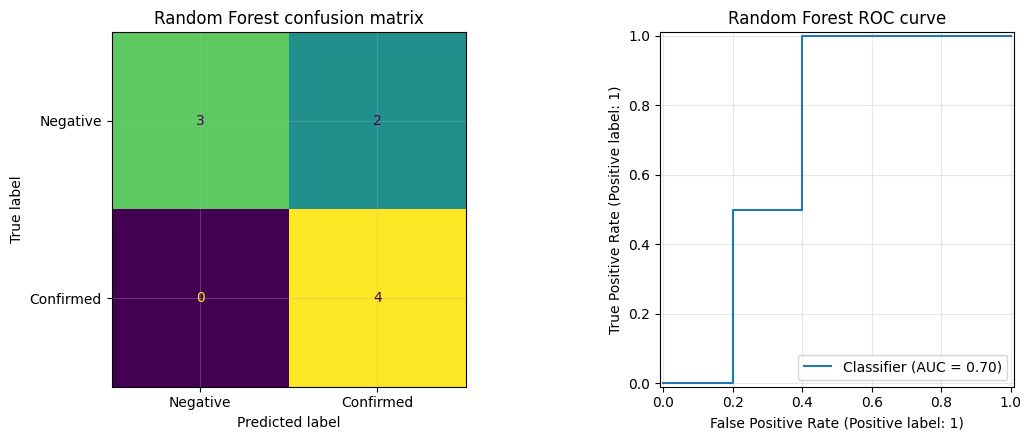

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Confirmed"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"{best_model_name} confusion matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"{best_model_name} ROC curve")

plt.tight_layout()
plt.show()

# Error analysis

A confusion matrix is useful, but it is still abstract. I want to inspect actual true positives, true negatives, false positives, and false negatives.

That lets me ask better questions. What does the model get confidently right? Which negative cases still look extremely planet-like? Which confirmed cases are hard to recover cleanly? Are the mistakes connected to weak depth, noisy light curves, secondary events, or imperfect period recovery?

This is also the section I would lean on heavily during a presentation, because it shows that I understand the model as a behavior, not only as a score.

In [29]:
prediction_df = test_meta.copy().reset_index(drop=True)
prediction_df["actual"] = y_test.reset_index(drop=True)
prediction_df["predicted"] = y_pred
prediction_df["proba_confirmed"] = y_proba
prediction_df["case_type"] = np.select(
    [
        (prediction_df["actual"] == 1) & (prediction_df["predicted"] == 1),
        (prediction_df["actual"] == 0) & (prediction_df["predicted"] == 0),
        (prediction_df["actual"] == 0) & (prediction_df["predicted"] == 1),
        (prediction_df["actual"] == 1) & (prediction_df["predicted"] == 0),
    ],
    ["True Positive", "True Negative", "False Positive", "False Negative"],
    default="Other"
)

prediction_df.to_csv(PREDICTIONS_PATH, index=False)
prediction_df.sort_values("proba_confirmed", ascending=False)

,kepid,kepoi_name,koi_disposition,actual,predicted,proba_confirmed,case_type
8,5040223,K04354.01,FALSE POSITIVE,0,1,0.675547,False Positive
4,8081899,K02426.01,CONFIRMED,1,1,0.663640,True Positive
2,10905911,K02754.01,CONFIRMED,1,1,0.610068,True Positive
1,11463211,K00770.01,FALSE POSITIVE,0,1,0.586486,False Positive
5,10166274,K01078.02,CONFIRMED,1,1,0.571164,True Positive
7,5080636,K01843.01,CONFIRMED,1,1,0.564757,True Positive
6,10219288,K07993.01,FALSE POSITIVE,0,0,0.412044,True Negative
3,9790965,K07231.01,FALSE POSITIVE,0,0,0.276217,True Negative
0,4579598,K04414.01,FALSE POSITIVE,0,0,0.243080,True Negative


In [30]:
prediction_df["case_type"].value_counts()

case_type
True Positive     4
True Negative     3
False Positive    2
Name: count, dtype: int64

In [31]:
def select_representative_cases(pred_df: pd.DataFrame):
    selections = {}

    tp = pred_df[pred_df["case_type"] == "True Positive"].sort_values("proba_confirmed", ascending=False)
    tn = pred_df[pred_df["case_type"] == "True Negative"].sort_values("proba_confirmed", ascending=True)
    fp = pred_df[pred_df["case_type"] == "False Positive"].sort_values("proba_confirmed", ascending=False)
    fn = pred_df[pred_df["case_type"] == "False Negative"].sort_values("proba_confirmed", ascending=True)

    if len(tp) > 0:
        selections["True Positive"] = tp.iloc[0]
    if len(tn) > 0:
        selections["True Negative"] = tn.iloc[0]
    if len(fp) > 0:
        selections["False Positive"] = fp.iloc[0]
    if len(fn) > 0:
        selections["False Negative"] = fn.iloc[0]

    return selections

representative_cases = select_representative_cases(prediction_df)
list(representative_cases.keys())

['True Positive', 'True Negative', 'False Positive']

In [32]:
for case_name, case_row in representative_cases.items():
    print("=" * 80)
    print(case_name)
    print(case_row[["kepid", "kepoi_name", "koi_disposition", "actual", "predicted", "proba_confirmed"]])

True Positive
kepid                8081899
kepoi_name         K02426.01
koi_disposition    CONFIRMED
actual                     1
predicted                  1
proba_confirmed      0.66364
Name: 4, dtype: object
True Negative
kepid                     4579598
kepoi_name              K04414.01
koi_disposition    FALSE POSITIVE
actual                          0
predicted                       0
proba_confirmed           0.24308
Name: 0, dtype: object
False Positive
kepid                     5040223
kepoi_name              K04354.01
koi_disposition    FALSE POSITIVE
actual                          0
predicted                       1
proba_confirmed          0.675547
Name: 8, dtype: object


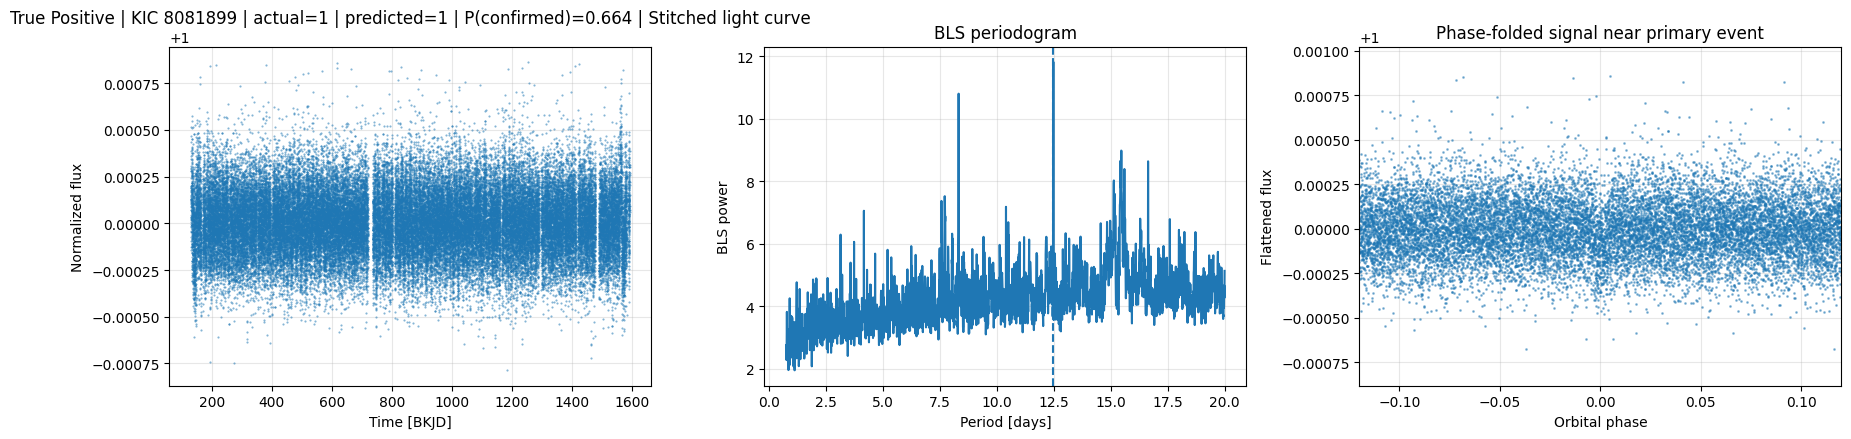

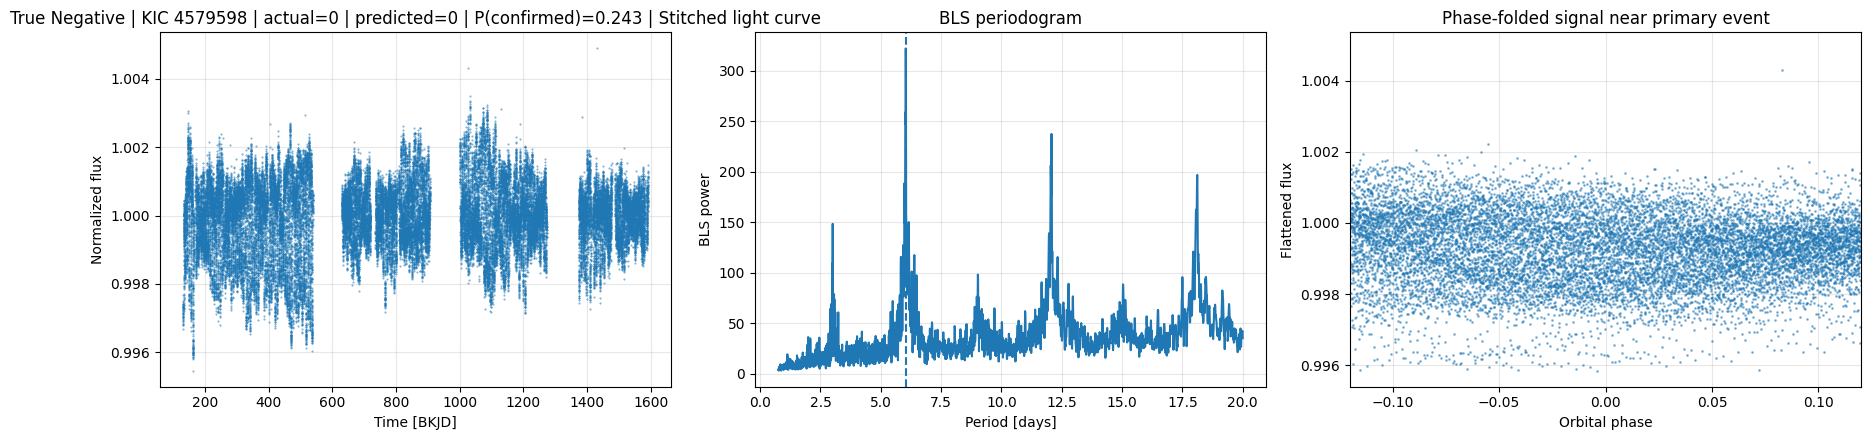

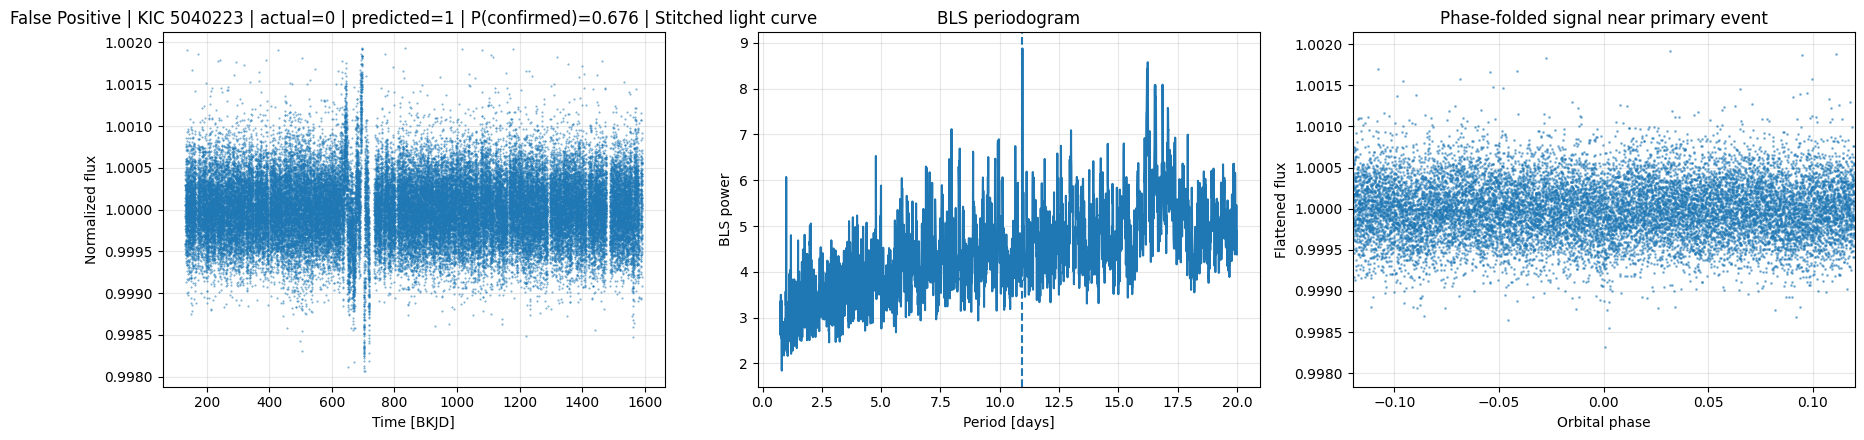

In [33]:
for case_name, case_row in representative_cases.items():
    title = (
        f"{case_name} | KIC {int(case_row['kepid'])} | "
        f"actual={int(case_row['actual'])} | predicted={int(case_row['predicted'])} | "
        f"P(confirmed)={case_row['proba_confirmed']:.3f}"
    )
    _ = plot_target_diagnostics(int(case_row["kepid"]), title_prefix=title + " | ")

## Interpreting the mistake patterns

When I look at false positives in this context, I need to remember that the negative class is not made of empty stars with no interesting behavior. Many negative cases can still contain strong repeating dips. That is why they are hard. Some may show secondary events, some may show odd-even differences, and some may simply look convincing in a compact feature space.

False negatives are useful for a different reason. They show me where confirmed planets still fail to look sufficiently planet-like to the current feature set and model. Weak signals, noisy baselines, limited phase coverage, or imperfect period recovery can all make a confirmed case look less compelling than it really is.

This section is not extra decoration. It tells me what the next version of the project should improve.

# Interpreting the model itself

A model score tells me how well the model separates the classes. Feature importance tells me what kind of evidence it relies on most strongly.

If the top features include quantities such as recovered signal-to-noise, depth relative to noise, odd-even behavior, secondary-event behavior, or period-recovery quality, that is reassuring. Those are exactly the kinds of clues I would expect to matter in a transit-vetting problem.

In [34]:
if best_model_name == "Random Forest":
    fitted_model = best_pipeline.named_steps["model"]
    importance_df = pd.DataFrame({
        "feature": model_features,
        "importance": fitted_model.feature_importances_
    }).sort_values("importance", ascending=False)
else:
    fitted_model = best_pipeline.named_steps["model"]
    importance_df = pd.DataFrame({
        "feature": model_features,
        "importance": fitted_model.coef_[0]
    }).sort_values("importance", key=np.abs, ascending=False)

importance_df.to_csv(FEATURE_IMPORTANCE_PATH, index=False)
importance_df.head(20)

,feature,importance
13,duty_cycle,0.073999
1,time_baseline_days,0.057957
15,in_transit_fraction,0.057496
18,phase_curve_scatter,0.051823
14,estimated_transit_count,0.048524
28,period_recovery_relative_error,0.046816
11,bls_best_depth_snr,0.043736
22,odd_even_depth_difference,0.042401
10,bls_best_power,0.041646
7,bls_best_period,0.039275


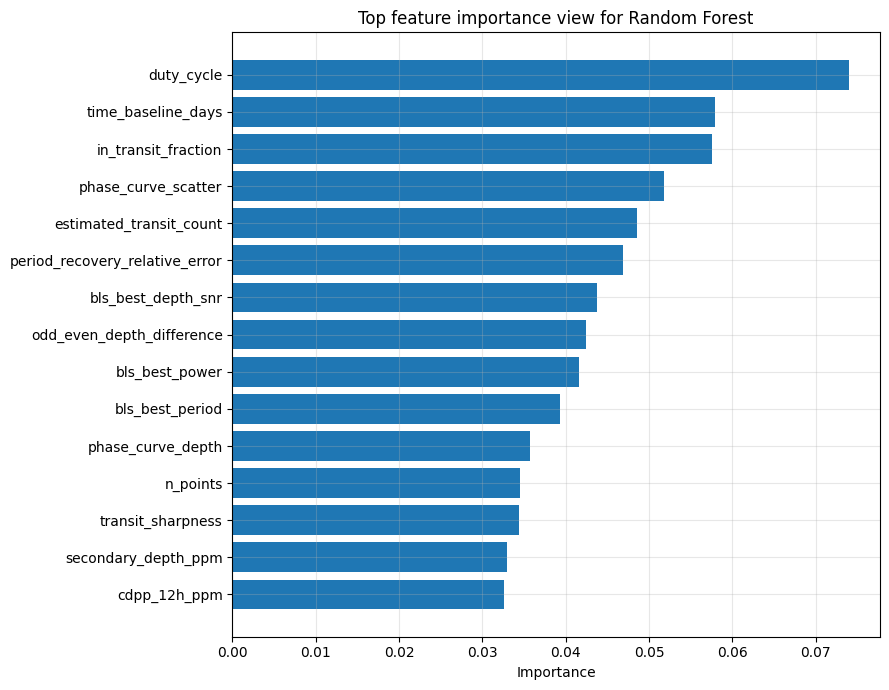

In [35]:
fig, ax = plt.subplots(figsize=(9, 7))
top_imp = importance_df.head(15).iloc[::-1]
ax.barh(top_imp["feature"], top_imp["importance"])
ax.set_title(f"Top feature importance view for {best_model_name}")
ax.set_xlabel("Importance" if best_model_name == "Random Forest" else "Coefficient")
plt.tight_layout()
plt.show()

# Optional interactive notebook moment

If I want to add a live moment, I can use Lightkurve’s interactive BLS view inside Jupyter Lab. I am leaving the cell below commented because it depends on the frontend environment being configured well, but it can be useful as an extra demonstration.

In [36]:
# Optional interactive view in Jupyter Lab:
stitched, flattened = download_and_prepare_lightcurve(example_confirmed)
flattened.interact_bls()

# Final conclusion

This notebook gives me a defensible first version of the project.

I start with real Kepler archive objects. I retrieve the light curves, clean and flatten them, search for transit-like signals with Box Least Squares, convert the recovered signal into a structured feature vector, and train a first classifier that tries to separate confirmed cases from stronger negative cases.

That already proves something important. The project is not only an idea. It already has a working pipeline from archive object to machine-learning decision.

It is still a prototype, and I want to be honest about that. The sample is small, the feature set is still first-generation, and the benchmark design is practical rather than final. But the workflow is already coherent, explainable, and strong enough to present as a serious first version.